<a href="https://colab.research.google.com/github/BoufenoucheBouchra/Introduction-Apprentissage-Automatique/blob/main/TP6_M2_bioinfo_IAA_classification_de_sequences_de_proteines_avec_des_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# M2 bioinfo Introduction Apprentissage Automatique
## TP6 introduction aux RNN : un exemplde de classification de séquences de protéines avec des LSTM

### Auteur : Jérôme Farinas (2024)

### Source : [article "Using Deep Learning to Annotate the Protein Universe" (2019)](https://www.biorxiv.org/content/10.1101/626507v4.full)

### Nom :Boufenouche
### Prenom : Bouchra


In [ ]:
!apt install tree --quiet

%matplotlib inline

import os
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from prettytable import PrettyTable
from IPython.display import Image

from keras.callbacks import EarlyStopping
from keras.utils import to_categorical
from keras.preprocessing.sequence import pad_sequences

Reading package lists...
Building dependency tree...
Reading state information...
tree is already the newest version (2.0.2-1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.


In [ ]:
!rm -rf /content/m2-bioinfo
# Récupération des données
!git clone https://gitlab.com/jeromefarinas/m2-bioinfo.git

!tree /content/m2-bioinfo

Cloning into 'm2-bioinfo'...
remote: Enumerating objects: 115, done.
remote: Counting objects: 100% (115/115), done.
remote: Compressing objects: 100% (112/112), done.
remote: Total 115 (delta 0), reused 108 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (115/115), 246.00 MiB | 24.65 MiB/s, done.
Updating files: 100% (202/202), done.
/content/m2-bioinfo
├── README.md
└── RNN
    └── random_split
        ├── dev
        │   ├── data-00000-of-00010
        │   ├── data-00001-of-00010
        │   ├── data-00002-of-00010
        │   ├── data-00003-of-00010
        │   ├── data-00004-of-00010
        │   ├── data-00005-of-00010
        │   ├── data-00006-of-00010
        │   ├── data-00007-of-00010
        │   ├── data-00008-of-00010
        │   └── data-00009-of-00010
        ├── random_split
        │   ├── dev
        │   │   ├── data-00000-of-00010
        │   │   ├── data-00001-of-00010
        │   │   ├── data-00002-of-00010
        │   │   ├── data-00003-of-00010
        │

In [ ]:
data = pd.read_csv("/content/m2-bioinfo/RNN/random_split/random_split/train/data-00011-of-00080")
data.head()

,family_id,sequence_name,family_accession,aligned_sequence,sequence
0,YfcL,Q5E3V0_VIBF1/3-85,PF08891.11,IEFEEKMLELIDARIESASD.DELFAGGYLRGHISLSVANCEEQGI...,IEFEEKMLELIDARIESASDDELFAGGYLRGHISLSVANCEEQGIN...
1,Somatomedin_B,F2UGX0_SALR5/258-297,PF01033.17,TTCAVRG...C..........SDINL......NQNCQCD.PSC.YS...,TTCAVRGCSDINLNQNCQCDPSCYSFGDCCADFAAVCESS
2,Surp,K7J3U9_NASVI/11-59,PF01805.20,RNIIDKLAQFVA..R..NG....P........EFEQMT.KNK.......,RNIIDKLAQFVARNGPEFEQMTKNKQKDNPKFSFLFGGEYFNYYQYKVT
3,DUF1230,E1ZG39_CHLVA/70-212,PF06799.11,.AVPREQRPVNELQQLKDTPLLAW......ATLDL..PQYAQRL.....,AVPREQRPVNELQQLKDTPLLAWATLDLPQYAQRLLILYGGVFLLL...
4,SRCR_2,F1NY88_CHICK/145-241,PF15494.6,GPNFILEVYSPVSQTWYPVCQDDWTDDFGKIACEDMGYN....VDT...,GPNFILEVYSPVSQTWYPVCQDDWTDDFGKIACEDMGYNVDTYYYS...


In [ ]:
data_path = "/content/m2-bioinfo/RNN/random_split/random_split"
print("Partitionnements disponibles : ", os.listdir(data_path))

Partitionnements disponibles :  ['train', 'dev', 'test']


In [ ]:
def Read_Concating_data(partition, path = data_path):
  data = []
  for fn in os.listdir(os.path.join(path, partition)):
    with open(os.path.join(path, partition, fn)) as f:
       data.append(pd.read_csv(f, index_col = None))
  return pd.concat(data)

# lecture des données
df_train = Read_Concating_data("train")
df_val = Read_Concating_data("dev") #l'évaluation pendant l’entraînement.
df_test = Read_Concating_data("test") #l’évaluation finale


## Statistiques basiques

In [ ]:
# Taille des données
print('Train size: ', len(df_train))
print('Val size: ', len(df_val))
print('Test size: ', len(df_test))

Train size:  1086741
Val size:  126171
Test size:  126171


In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1086741 entries, 0 to 13473
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   family_id         1086741 non-null  object
 1   sequence_name     1086741 non-null  object
 2   family_accession  1086741 non-null  object
 3   aligned_sequence  1086741 non-null  object
 4   sequence          1086741 non-null  object
dtypes: object(5)
memory usage: 49.7+ MB


In [ ]:
df_train.head()

,family_id,sequence_name,family_accession,aligned_sequence,sequence
0,Ribosomal_S3_C,I7HEJ8_9HELI/120-202,PF00189.20,IATQLEKRVAFRRAMKKVMQAAM.K......A.G..AKGIKVKVSG...,IATQLEKRVAFRRAMKKVMQAAMKAGAKGIKVKVSGRLAGAEMART...
1,DUF2114,A3CU80_METMJ/40-497,PF09887.9,PYFIVASVEMGNTTTKCILTGTNLETGRSYVINKTVTMSRDVRPPK...,PYFIVASVEMGNTTTKCILTGTNLETGRSYVINKTVTMSRDVRPPK...
2,Coprogen_oxidas,K4IEE8_PSYTT/5-300,PF01218.18,.FYNYIQNLQDTITSK.LESVD.......................G...,FYNYIQNLQDTITSKLESVDGTATFFEDIWERKEGGGGRTRVIENG...
3,Flavokinase,A0A212EJD8_DANPL/6-132,PF01687.17,..LPLFLKGQVVNGFGR.GSKD.L.........GCPTA......NF...,LPLFLKGQVVNGFGRGSKDLGCPTANFPREVAQSLPKDLKTGVYYG...
4,TFR_dimer,A2BGQ8_DANRE/619-737,PF04253.15,ISMESLKKAVQFFRDTATKLDRLIRD.SD....................,ISMESLKKAVQFFRDTATKLDRLIRDSDLVKETPLKARRINDQLML...


In [ ]:
# Exemple de séquence non alignée
# chaque caractère représente un des 24 acides aminés possibles (20 communs + 4 rares) dans la séquence.

df_train.head(1)['sequence'].values[0]

'IATQLEKRVAFRRAMKKVMQAAMKAGAKGIKVKVSGRLAGAEMARTEWYMEGRVPLHTLRAKIDYGFAEAMTTYGIIGVKVWI'

In [ ]:
# Taille des données brutes
print('Train size: ', len(df_train))
print('Val size: ', len(df_val))
print('Test size: ', len(df_test))

Train size:  1086741
Val size:  126171
Test size:  126171


In [ ]:
def calc_unique_cls(train, test, val):
  """
  Affiche le nombre unique de classes dans les jeux de données
  """
  train_unq = np.unique(train['family_accession'].values)
  val_unq = np.unique(val['family_accession'].values)
  test_unq = np.unique(test['family_accession'].values)

  print('Nombre de classes uniques dans Train : ', len(train_unq))
  print('Nombre de classes uniques dans Val   : ', len(val_unq))
  print('Nombre de classes uniques dans Test  : ', len(test_unq))

In [ ]:
# Unique classes in the given dataset : [df_train, df_val and df_test]

calc_unique_cls(df_train, df_test, df_val)

Nombre de classes uniques dans Train :  17929
Nombre de classes uniques dans Val   :  13071
Nombre de classes uniques dans Test  :  13071


## Comptage de séquences

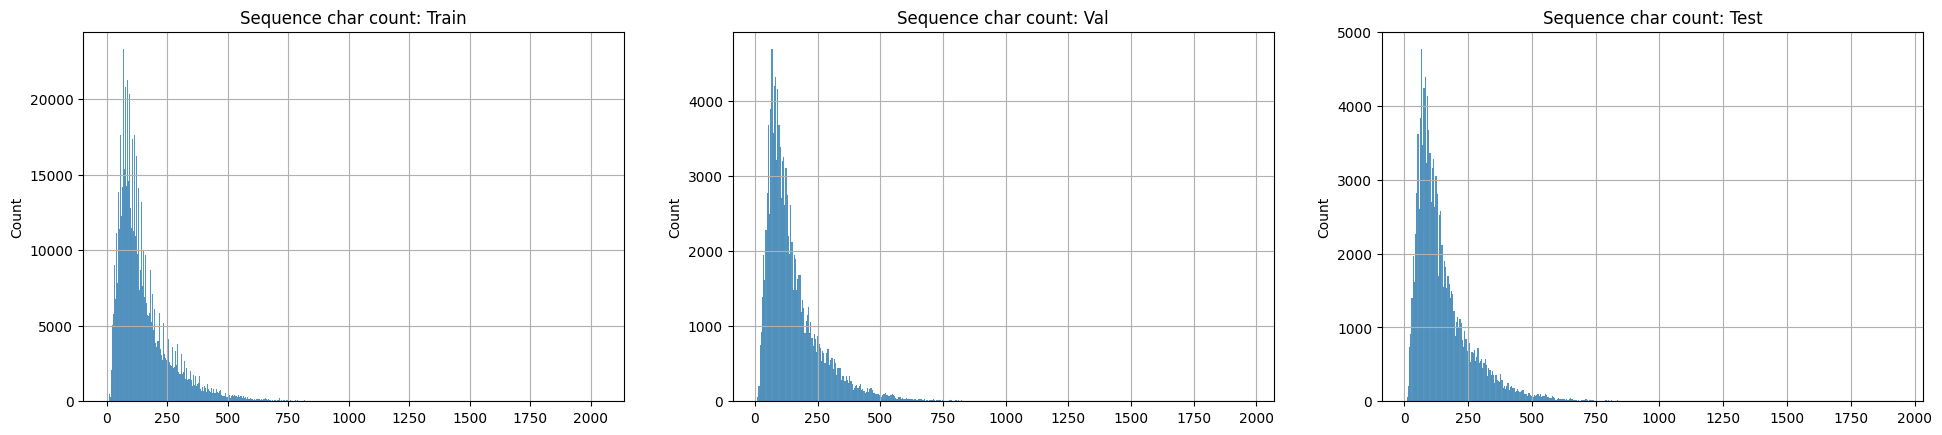

In [ ]:
# Length of sequence in train data.
df_train['seq_char_count']= df_train['sequence'].apply(lambda x: len(x)) #Pour chaque séquence x, on calcule sa longueur (le nombre de caractères).
df_val['seq_char_count']= df_val['sequence'].apply(lambda x: len(x))
df_test['seq_char_count']= df_test['sequence'].apply(lambda x: len(x))

def plot_seq_count(df, data_name):
  sns.histplot(df['seq_char_count'].values)
  plt.title(f'Sequence char count: {data_name}')
  plt.grid(True)

plt.subplot(1, 3, 1)
plot_seq_count(df_train, 'Train')

plt.subplot(1, 3, 2)
plot_seq_count(df_val, 'Val')

plt.subplot(1, 3, 3)
plot_seq_count(df_test, 'Test')

plt.subplots_adjust(right=3.0)
plt.show()

**Observations**

La plupart des séquences d'acides aminés non alignées ont un nombre de caractères compris entre 50 et 250.

## Fréquence des séquences des codes

Les séquences d'acides aminés sont représentées par leur code correspondant d'une lettre. Par exemple, le code de l'alanine est (A), celui de l'arginine (R) et ainsi de suite. La liste complète des acides aminés avec leur code est disponible [ici](https://fr.wikipedia.org/wiki/Code_g%C3%A9n%C3%A9tique#Table_des_codons_d'ARN_messager).

In [ ]:
def get_code_freq(df, data_name):
  df = df.apply(lambda x: " ".join(x)) #" ".join(x) va séparer chaque caractère par un espace "ATCG" devient "A T C G".

  codes = []
  for i in df: # concatination of all codes
    codes.extend(i) #codes contient tous les caractères de toutes les séquences, y compris les espaces.

  codes_dict= Counter(codes) #Counter fait un dictionnaire fréquence : {code: nombre d’occurrences}.
  codes_dict.pop(' ') # removing white space

  print(f'Codes: {data_name}')
  print(f'Total unique codes: {len(codes_dict.keys())}')

  df = pd.DataFrame({'Code': list(codes_dict.keys()), 'Freq': list(codes_dict.values())}) #Création d’un DataFrame avec les fréquences :
  return df.sort_values('Freq', ascending=False).reset_index()[['Code', 'Freq']] #Trie du plus fréquent au moins fréquent.


# train code sequence
train_code_freq = get_code_freq(df_train['sequence'], 'Train')
train_code_freq

Codes: Train
Total unique codes: 25


,Code,Freq
0,L,17062816
1,A,14384873
2,V,11913147
3,G,11845579
4,E,10859966
5,S,10597822
6,I,10234455
7,R,9406165
8,D,9371097
9,K,9127832


In [ ]:
# val code sequence
val_code_freq = get_code_freq(df_val['sequence'], 'Val')
val_code_freq

Codes: Val
Total unique codes: 22


,Code,Freq
0,L,1967025
1,A,1667703
2,V,1382128
3,G,1376124
4,E,1249356
5,S,1210750
6,I,1185722
7,R,1085950
8,D,1080572
9,K,1047638


In [ ]:
# test code sequence
test_code_freq = get_code_freq(df_test['sequence'], 'Test')
test_code_freq

Codes: Test
Total unique codes: 24


,Code,Freq
0,L,1967046
1,A,1668137
2,V,1380962
3,G,1375349
4,E,1251000
5,S,1210559
6,I,1184239
7,R,1085786
8,D,1078379
9,K,1045957


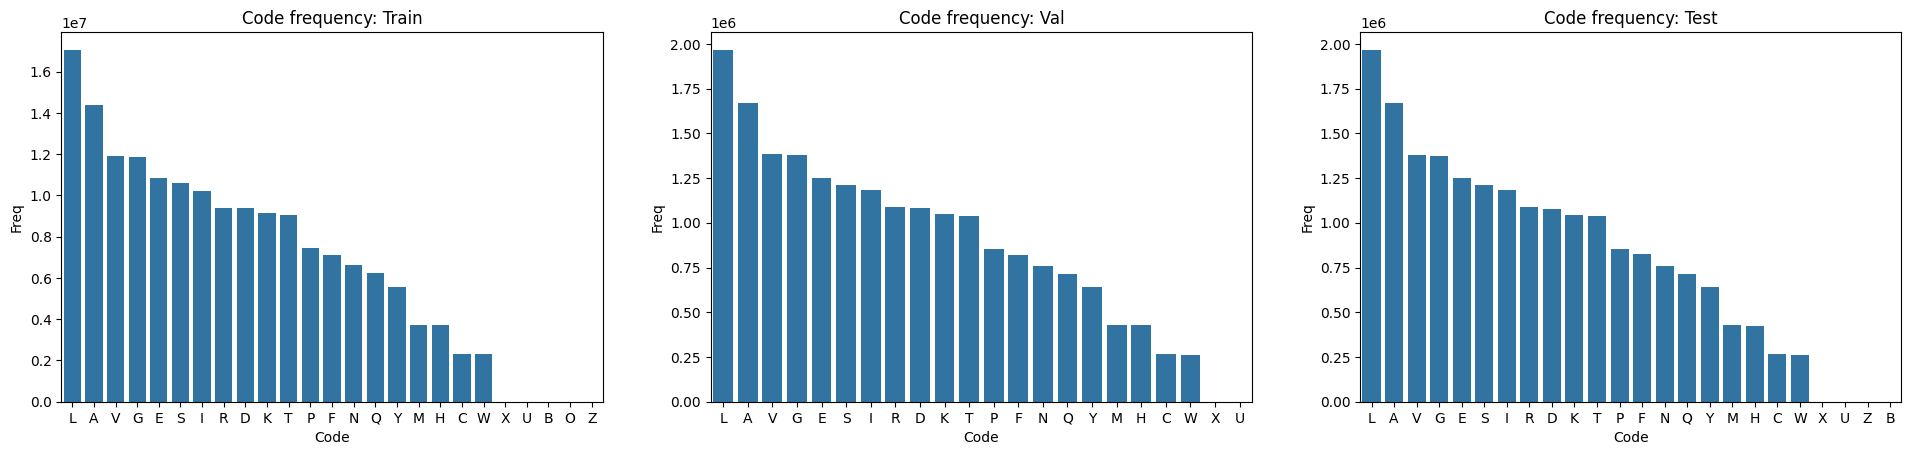

In [ ]:
def plot_code_freq(df, data_name):
  plt.title(f'Code frequency: {data_name}')
  sns.barplot(x='Code', y='Freq', data=df)

plt.subplot(1, 3, 1)
plot_code_freq(train_code_freq, 'Train')

plt.subplot(1, 3, 2)
plot_code_freq(val_code_freq, 'Val')

plt.subplot(1, 3, 3)
plot_code_freq(test_code_freq, 'Test')

plt.subplots_adjust(right=3.0)
plt.show()

**Observations**
* Le code d'acide aminé le plus fréquent est L, suivi de A, V et G.
* Comme nous pouvons le constater, les acides aminés peu courants (c'est-à-dire X, U, B, O, Z) sont présents en très faible quantité. Par conséquent, nous ne pouvons considérer que 20 acides aminés naturels courants pour le codage des séquences.




## Familles de protéines avec le plus grand nombre de séquences (nombre d'observations)


In [ ]:
df_train.groupby('family_id').size().sort_values(ascending=False).head(20)

,0
family_id,
Methyltransf_25,3637
LRR_1,1927
Acetyltransf_7,1761
His_kinase,1537
Bac_transf,1528
Lum_binding,1504
DNA_binding_1,1345
Chromate_transp,1265
Lipase_GDSL_2,1252


In [ ]:
df_val.groupby('family_id').size().sort_values(ascending=False).head(20)

,0
family_id,
Methyltransf_25,454
LRR_1,240
Acetyltransf_7,219
His_kinase,192
Bac_transf,190
Lum_binding,187
DNA_binding_1,168
Chromate_transp,157
Lipase_GDSL_2,156


In [ ]:
df_test.groupby('family_id').size().sort_values(ascending=False).head(20)

,0
family_id,
Methyltransf_25,454
LRR_1,240
Acetyltransf_7,219
His_kinase,192
Bac_transf,190
Lum_binding,187
DNA_binding_1,168
Chromate_transp,157
Lipase_GDSL_2,156


**Observations**
  * Les 20 premières classes sont les mêmes dans tous les ensembles [train, test, val].
  * Les ensembles Test et Val ont presque la même fréquence pour les 20 premières classes.

### Considérons 1000 classes basées sur le nombre d'observations.

In [ ]:
# Considérons les 1000 premières classes sur la base de la plupart des observations en raison de la puissance de calcul limitée.

classes = df_train['family_accession'].value_counts()[:1000].index.tolist()
len(classes)

1000

In [ ]:
# Filtrage des données sur la base des 1000 classes considérées.
train_sm = df_train.loc[df_train['family_accession'].isin(classes)].reset_index()
val_sm = df_val.loc[df_val['family_accession'].isin(classes)].reset_index()
test_sm = df_test.loc[df_test['family_accession'].isin(classes)].reset_index()

print('Data size after considering 1000 classes for each data split:')
print('Train size :', len(train_sm))
print('Val size :', len(val_sm))
print('Test size :', len(test_sm))

Data size after considering 1000 classes for each data split:
Train size : 439493
Val size : 54378
Test size : 54378


In [ ]:
# Nombre de classes uniques après réduction de la taille des données.

calc_unique_cls(train_sm, test_sm, val_sm)

Nombre de classes uniques dans Train :  1000
Nombre de classes uniques dans Val   :  1000
Nombre de classes uniques dans Test  :  1000


## Préparation des séquences

In [ ]:
# https://dmnfarrell.github.io/bioinformatics/mhclearning
# http://www.cryst.bbk.ac.uk/education/AminoAcid/the_twenty.html
# 1 letter code for 20 natural amino acids

codes = ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L',
         'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']

def create_dict(codes):
  char_dict = {}
  for index, val in enumerate(codes):
    char_dict[val] = index+1

  return char_dict

char_dict = create_dict(codes)

print(char_dict)
print("Dict Length:", len(char_dict))

{'A': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8, 'K': 9, 'L': 10, 'M': 11, 'N': 12, 'P': 13, 'Q': 14, 'R': 15, 'S': 16, 'T': 17, 'V': 18, 'W': 19, 'Y': 20}
Dict Length: 20


In [ ]:
def integer_encoding(data):
  """
  - Encode la séquence de code en valeurs entières.
  - 20 acides aminés communs sont pris en considération
    et les 4 autres sont classés comme 0.
  """

  encode_list = []
  for row in data['sequence'].values:
    row_encode = []
    for code in row:
      row_encode.append(char_dict.get(code, 0))
    encode_list.append(np.array(row_encode))

  return encode_list # Chaque élément  de encode_list est un np.array (vecteur d’entiers),exp Séquence : "MKTLLV" >Encodage : [13, 11, 17, 12, 12, 19] (selon le mapping de char_dict).


train_encode = integer_encoding(train_sm)
val_encode = integer_encoding(val_sm)
test_encode = integer_encoding(test_sm)

In [ ]:
train_encode[1] # le vecteur d'une seule séquence  ( l'encoddage d'une seule séquence)

array([ 5, 20, 12, 20,  8, 14, 12, 10, 14,  3, 17,  8, 17, 16,  9, 10,  4,
       16, 18,  3,  6, 17,  1, 17,  5,  5,  4,  3,  8, 19,  4, 15,  9,  4,
        6,  6,  6,  6, 15, 17, 15, 18,  8,  4, 12,  6, 16, 18,  5,  4,  9,
        6,  6, 18, 12,  8, 16,  1, 18,  7,  6,  3, 10, 13,  4,  1, 11, 14,
       12, 20,  5, 12, 18, 14,  3,  2,  3,  5,  5,  1,  2,  6,  8, 16,  8,
       18, 10,  7, 13,  9, 12, 13, 11, 18, 13, 17, 18,  7,  1, 12,  5, 15,
       20,  5,  4, 11, 20, 12,  9,  7,  6,  9, 18, 18,  3, 14, 19,  5,  6,
        6,  6, 14,  3, 10, 17, 13, 20, 20, 10,  5,  4,  4,  3, 18,  8,  7,
        5,  7, 15, 18, 16,  9, 10,  1,  2,  3, 13,  5,  6,  1,  3, 10, 20,
       13,  3, 20,  9,  3, 12,  2,  3, 15, 20,  5, 19, 12,  1,  7, 15, 12,
        4,  1, 15,  6, 18,  6,  6, 10,  5,  5,  3, 20, 10,  9, 13, 17, 16,
        9, 15, 16, 10,  4,  4,  8, 20, 12,  5,  8, 17,  1,  2,  6,  3, 15,
        5, 10,  4,  1, 20, 18, 13,  8, 18,  4,  1, 15,  9, 17, 10,  3, 20,
       17,  9,  4, 14, 15

In [ ]:
# padding des séquences + limitations at 50k/5k/5k (memory considerations)
#Limitation du nombre d'échantillons pour éviter un problème de mémoire.Seulement 50k séquences pour train, 5k pour val, 5k pour test.
max_length = 100 #Chaque séquence (déjà encodée en entiers avec la fonction précédente) va être mise à la même longueur 100. car Les réseaux de neurones attendent des entrées de taille fixe.
train_pad = pad_sequences(train_encode, maxlen=max_length, padding='post', truncating='post')[:50000] #pad_sequences :Ajuste toutes les séquences pour qu’elles aient exactement 100 entiers.Si une séquence est plus courte que 100>padding (ajout de 0) à la fin (padding='post')
val_pad = pad_sequences(val_encode, maxlen=max_length, padding='post', truncating='post')[:5000]
test_pad = pad_sequences(test_encode, maxlen=max_length, padding='post', truncating='post')[:5000]

train_pad.shape, val_pad.shape, test_pad.shape
#EXP : train_pad : 50 000 séquences × 100 tokens (toutes les séquences des vecteurs de taille fixe = 100 (avec padding ou troncature)).

((50000, 100), (5000, 100), (5000, 100))

In [ ]:
train_pad[0] #train_pad est un numpy array après le pad_sequences
#Chaque ligne = une séquence encodée en entiers (longueur fixée à max_length = 100).
""" ici on regarde que la premiere séquence
l’interprétation : Chaque entier correspond à un acide aminé (via ton dictionnaire char_dict).Par ex. 11 pourrait être "L", 10 "K", 15 "P", etc.
On as exactement 100 entiers → donc la séquence a été :
soit tronquée si elle était plus longue que 100,
soit paddée avec des 0 si elle était plus courte (ici je ne vois pas de 0, donc la séquence originale avait ≥100 aa)."""

' ici on regarde que la premiere séquence\nl’interprétation : Chaque entier correspond à un acide aminé (via ton dictionnaire char_dict).Par ex. 11 pourrait être "L", 10 "K", 15 "P", etc.\nOn as exactement 100 entiers → donc la séquence a été :\nsoit tronquée si elle était plus longue que 100,\nsoit paddée avec des 0 si elle était plus courte (ici je ne vois pas de 0, donc la séquence originale avait ≥100 aa).'

In [ ]:
# Encodage "One hot" des séquences + limitations at 50k/5k/5k (memory considerations) ,passer de l’encodage entier à l’encodage one-hot.
train_ohe = to_categorical(train_pad)[:50000]
val_ohe = to_categorical(val_pad)[:5000]
test_ohe = to_categorical(test_pad)[:5000]

train_ohe.shape, test_ohe.shape, test_ohe.shape


#1.to_categorical(train_pad) : Chaque entier de train_pad (qui allait de 0 à 20 grâce à char_dict) est transformé en un vecteur one-hot.
#Exemple :Si char_dict["A"] = 1, alors "A" → [0,1,0,0,...,0] (longueur 21).Si "L" = 11 → [0,0,0,0,0,0,0,0,0,0,1,0,...,0].
#Si code = 0 (acide aminé inconnu/padding) → [1,0,0,...,0].
#2. La nouvelle shape : Avant : train_pad.shape = (50000, 100)→ 50 000 séquences, chacune de longueur 100 entiers.
#près : train_ohe.shape = (50000, 100, 21)
#→ 50 000 séquences,
#→ chaque séquence a 100 positions,
#→ chaque position est représentée par un vecteur one-hot de taille 21 (20 aa + 1 catégorie "inconnue/padding")."""

((50000, 100, 21), (5000, 100, 21), (5000, 100, 21))

In [ ]:
# label/integer encoding output variable: (y)
# LabelEncoder() :C’est un outil de scikit-learn qui transforme des étiquettes catégorielles (chaînes de caractères) en entiers.
from sklearn.preprocessing import LabelEncoder  #exp :classes = ["PF00001", "PF00002", "PF00099"]LabelEncoder().fit_transform(classes) # -> [0, 1, 2]"""
le = LabelEncoder()

y_train_le = le.fit_transform(train_sm['family_accession']) #fit :apprend la correspondance unique entre chaque famille (PFxxxxx) et un entier.transform: applique cette correspondance aux données train.exp :"PF00001" → 0,"PF00002" → 1,"PF99999" → 2
y_val_le = le.transform(val_sm['family_accession']) #On applique le même mapping appris sur train aux datasets validation et test.
y_test_le = le.transform(test_sm['family_accession'])

y_train_le.shape, y_val_le.shape, y_test_le.shape

#(439493,) → y_train_le contient 439 493 labels (un entier par séquence d’entraînement).
#(54378,) → y_val_le contient 54 378 labels (jeu de validation).
#(54378,) → y_test_le contient aussi 54 378 labels (jeu de test).
#1D (d’où (n,))."""

((439493,), (54378,), (54378,))

In [ ]:
print('Total classes: ', len(le.classes_)) #1000 familles de protéines différentes dans le jeu de

Total classes:  1000


In [ ]:
# One hot encoding of outputs
#from keras.utils import to_categorical
y_train = to_categorical(y_train_le)[:50000] #to_categorical(y_train_le) : Transforme chaque entier (0 à 999) en un vecteur one-hot de taille 1000 (le nombre total de classes).
y_val = to_categorical(y_val_le)[:5000]
y_test = to_categorical(y_test_le)[:5000]

y_train.shape, y_val.shape, y_test.shape


# EXP :  y_train_le[0] = 3  > to_categorical(y_train_le[0]) -> [0,0,0,1,0,...,0]  # longueur = 1000

# resultat : y_train.shape >  50 000 séquences, chacune représentée par un vecteur one-hot de 1000 classes.

((50000, 1000), (5000, 1000), (5000, 1000))

In [ ]:
# Fonction utilitaire : trace la précision et la perte du modèle
# https://realpython.com/python-keras-text-classification/

plt.style.use('ggplot')

def plot_history(history):
  acc = history.history['accuracy']
  val_acc = history.history['val_accuracy']
  loss = history.history['loss']
  val_loss = history.history['val_loss']
  x = range(1, len(acc) + 1)

  plt.figure(figsize=(12, 5))
  plt.subplot(1, 2, 1)
  plt.plot(x, acc, 'b', label='Training acc')
  plt.plot(x, val_acc, 'r', label='Validation acc')
  plt.title('Training and validation accuracy')
  plt.legend()

  plt.subplot(1, 2, 2)
  plt.plot(x, loss, 'b', label='Training loss')
  plt.plot(x, val_loss, 'r', label='Validation loss')
  plt.title('Training and validation loss')
  plt.legend()

In [ ]:
# Fonction utilitaire : Affichage du score du modèle (perte et précision) pour tous les ensembles.

def display_model_score(model, train, y_train, val, y_val, test, y_test, batch_size):

  train_score = model.evaluate(train, y_train, batch_size=batch_size, verbose=1)
  print('Train loss: ', train_score[0])
  print('Train accuracy: ', train_score[1])
  print('-'*70)

  val_score = model.evaluate(val, y_val, batch_size=batch_size, verbose=1)
  print('Val loss: ', val_score[0])
  print('Val accuracy: ', val_score[1])
  print('-'*70)

  test_score = model.evaluate(test, y_test, batch_size=batch_size, verbose=1)
  print('Test loss: ', test_score[0])
  print('Test accuracy: ', test_score[1])

## Classification LSTM simple

Commençons par un LSTM sur une simple couche.

In [ ]:
from tensorflow.keras.layers import Input, Embedding, Dropout, Dense, LSTM
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.regularizers import l2

x_input = Input(shape=(100,)) #shape=(100,) signifie que chaque échantillon est une séquence de longueur 100.
emb = Embedding(21, 128)(x_input) #21:taille du vocabulaire (20 acides aminés + 1 pour le padding).128:dimension des vecteurs denses (embedding size).Résultat:chaque entier de la séquence est transformé en vecteur 128D.
simple_rnn = LSTM(64, kernel_regularizer=l2(0.01))(emb) #LSTM avec 64 unités cachées.kernel_regularizer=l2(0.01): applique une régularisation L2 sur les poids de l’unité pour éviter le surapprentissage.
#x = Dropout(0.3)(simple_rnn):Si activé, il met à zéro 30% des neurones de la sortie LSTM pendant l’entraînement pour régularisation >Utile si le modèle surapprend.

# softmax classifier
x_output = Dense(1000, activation='softmax')(simple_rnn) #Couche finale pour la classification 1000 classes.| softmax → produit des probabilités pour chaque classe.

model1 = Model(inputs=x_input, outputs=x_output)
model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model1.summary()



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, 100, 128)       │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1000)           │        65,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,096 (457.41 KB)

 Trainable params: 117,096 (457.41 KB)

 Non-trainable params: 0 (0.00 B)

"" Vocabulaire = 21, embedding size = 128 | Paramètres : 21 * 128 = 2,688 ,Sortie : (batch_size, 100, 128) → chaque entier est transformé en vecteur de 128 dimensions.
paramétres de LSTM : params=4×((units+input_dim)×units+units) > inits=64 , input_dim =128 donc param=4*((128+64)*64+64)=49408
paramétre coouche dense = (64*1000)+1000(biais)=64000+1000=65000 | 1 biais par neurone×1000 neurones=1000 |Input dimension = 64 (sortie de LSTM) , Output dimension = 1000 (nombre de neurones de la Dense)

In [ ]:
# Early Stopping : mise en place d'un arret de l'apprentissage en cas de stagnation ou régression
es = EarlyStopping(monitor='val_loss', patience=3, verbose=1) #permet d’arrêter l’entraînement automatiquement si le modèle cesse de s’améliorer.

In [ ]:
history1 = model1.fit(
    train_pad, y_train,
    epochs=50, batch_size=256,
    validation_data=(val_pad, y_val),
    callbacks=[es]
    )


Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.0066 - loss: 7.3192 - val_accuracy: 0.0102 - val_loss: 6.6894
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.0163 - loss: 6.3522 - val_accuracy: 0.0246 - val_loss: 5.8293
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.0267 - loss: 5.7684 - val_accuracy: 0.0340 - val_loss: 5.5960
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.0345 - loss: 5.5461 - val_accuracy: 0.0384 - val_loss: 5.3851
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.0438 - loss: 5.3217 - val_accuracy: 0.0500 - val_loss: 5.2209
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.0526 - loss: 5.1194 - val_accuracy: 0.0566 - val_loss: 4.9994
Epoch 7/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.0612 - loss: 4.9751 - val_accuracy: 0.0744 - val_loss: 4.8430
Epoch 8/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.0797 - loss: 4.7971 - val_accu

 Résultats :
Accuracy très faible (~18-21%):Pour 1000 classes, une précision aléatoire serait ~0.1% si les classes sont équilibrées (1/1000), mais ici c'est déjà un peu mieux (~20%).Le modèle a appris quelque chose, mais très peu.
Loss élevée(~3.8-4) : Avec categorical_crossentropy, plus la loss est grande, moins le modèle est confiant dans ses prédictions.
Validation vs train :Train et val accuracy sont très proches → pas de surapprentissage important.
Les métriques bougent lentement → le modèle apprend très lentement.
Explication (Pourquoi ces résultats):
Grand nombre de classes (1000) → difficile pour un modèle simple d'atteindre une précision élevée rapidement.
LSTM seul avec 64 unités → peut-être pas assez puissant pour capturer toute la complexité de la séquence.
Taille de batch importante (256) → peut ralentir la convergence si le dataset est petit ou varié.
Pas de Dropout / pas de couche intermédiaire Dense → régularisation minimale.
A tester :
Augmenter la taille du LSTM : 128 ou 256 unités.
Ajouter une ou deux Dense intermédiaires avant le softmax.
Dropout après LSTM (ex: 0.3) pour stabiliser l'apprentissage.
Réduire la taille du batch (128 ou 64) pour voir si ça améliore la convergence.
Vérifier le prétraitement des données : les séquences doivent être bien encodées et équilibrées.

In [ ]:
# Sauvegarde des poids du modèle
#model1.save_weights('/content/drive/My Drive/Case_Study/pfam/model1.weigts.h5')

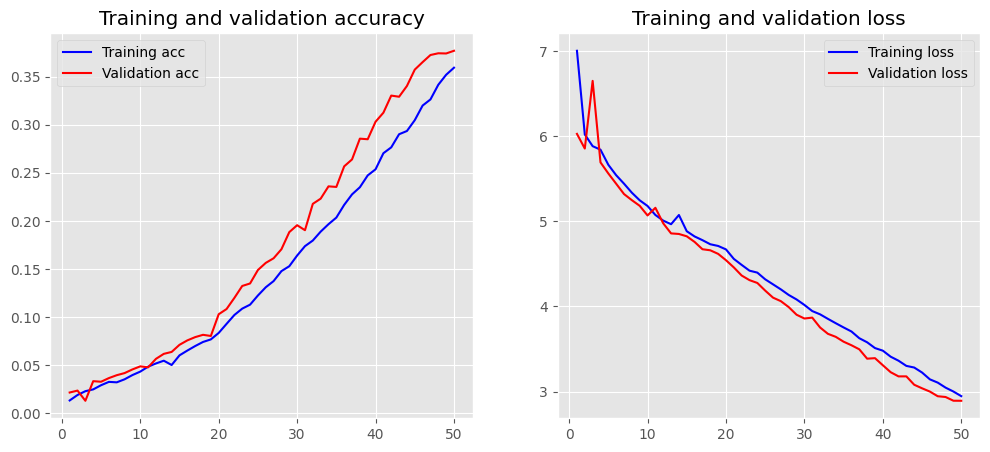

In [ ]:
plot_history(history1)
#Train ≈ Val pour loss et accuracy → le modèle ne mémorise pas juste les données d’entraînement
#Accuracy faible mais loss décroissante → le modèle apprend progressivement les relations dans les séquences.

In [ ]:
display_model_score(model1, train_pad, y_train, val_pad, y_val, test_pad, y_test, batch_size=256)


196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6226 - loss: 1.7186
Train loss:  1.7310305833816528
Train accuracy:  0.6194800138473511
----------------------------------------------------------------------
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5565 - loss: 2.0245
Val loss:  2.016174554824829
Val accuracy:  0.5568000078201294
----------------------------------------------------------------------
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5475 - loss: 2.0383
Test loss:  2.030120611190796
Test accuracy:  0.5547999739646912



"""La fonction va évaluer le modèle sur les trois ensembles et afficher :
Train loss & accuracy → performance sur l'ensemble d'entraînement
Validation loss & accuracy → performance sur l'ensemble de validation
Test loss & accuracy → performance sur l'ensemble test (jamais vu par le modèle)

***A vous de jouer maintenant !***

Lisez l'article qui présente les [données PFAM](https://www.biorxiv.org/content/10.1101/626507v4.full). Où se situe l'état de l'art sur ces données ? Décrivez succintement les différentes techniques qui ont été essayés sur ce corpus.

Reprenez la préparation des données : visualisez les fichiers, comprenez bien les différentes étapes. Rédigez un résumé de ces étapes.

Réalisez au minimum les apprentissages de LSTM suivants:
* Un LSTM avec deux couches
* Rajoutez du dropout sur les couches
* Créez un BiLSTM
* Créez un CNN suivi d'un LSTM

Testez différentes méthodes de régularisation.

Comparez ces différentes approches. Attention, j'ai du amputer sévèrement le corpus pour qu'il puisse tourner sur Google colab (principal problème : la mémoire occupée par les tenseurs des ensembles d'apprentissage/dev/test), vous n'arriverez pas à obtenir les mêmes résulats que dans l'article.

In [ ]:
x_input = Input(shape=(100,))
emb = Embedding(21, 128)(x_input)
simple_rnn = LSTM(128, return_sequences=True ,kernel_regularizer=l2(0.01))(emb)
x = Dropout(0.3)(simple_rnn)
simple_rnn2 = LSTM(64, kernel_regularizer=l2(0.01))(simple_rnn)
x = Dropout(0.3)(simple_rnn2)

# softmax classifier
x_output = Dense(1000, activation='softmax')(x)

model2 = Model(inputs=x_input, outputs=x_output)
model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model2.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_5 (Embedding)         │ (None, 100, 128)       │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 100, 128)       │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1000)           │        65,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 248,680 (971.41 KB)

 Trainable params: 248,680 (971.41 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Early Stopping : mise en place d'un arret de l'apprentissage en cas de stagnation ou régression
es2 = EarlyStopping(monitor='val_loss', patience=3, verbose=1)
history1 = model2.fit(
    train_pad, y_train,
    epochs=50, batch_size=256,
    validation_data=(val_pad, y_val),
    callbacks=[es2]
    )


Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.0096 - loss: 8.1096 - val_accuracy: 0.0216 - val_loss: 6.0282
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.0179 - loss: 6.1035 - val_accuracy: 0.0236 - val_loss: 5.8558
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.0229 - loss: 5.8566 - val_accuracy: 0.0130 - val_loss: 6.6510
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.0211 - loss: 6.0144 - val_accuracy: 0.0334 - val_loss: 5.6933
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.0294 - loss: 5.6892 - val_accuracy: 0.0328 - val_loss: 5.5629
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.0325 - loss: 5.5643 - val_accuracy: 0.0366 - val_loss: 5.4420
Epoch 7/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.0319 - loss: 5.4628 - val_accuracy: 0.0396 - val_loss: 5.3210
Epoch 8/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.0349 - loss: 5.3549 - val_accu

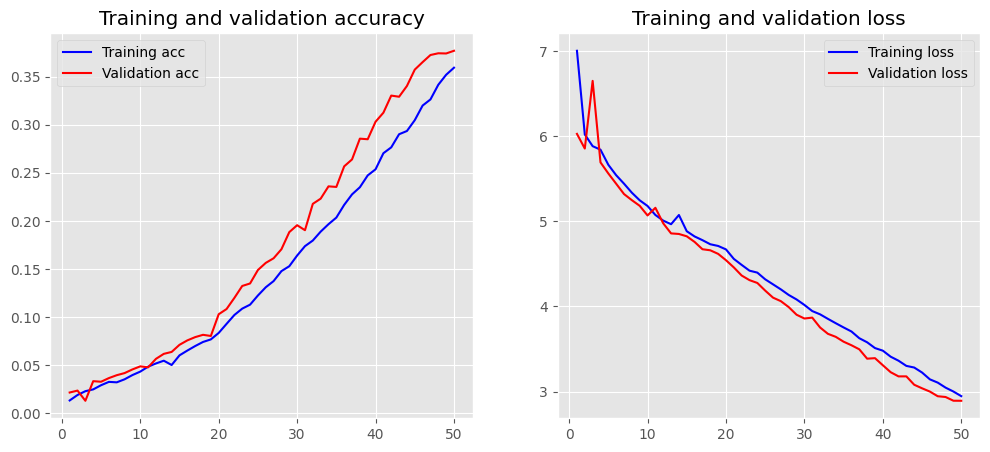

In [ ]:
plot_history(history1)

In [ ]:
display_model_score(model2, train_pad, y_train, val_pad, y_val, test_pad, y_test, batch_size=256)


196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.4202 - loss: 2.6704
Train loss:  2.6822855472564697
Train accuracy:  0.4180999994277954
----------------------------------------------------------------------
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3728 - loss: 2.9135
Val loss:  2.891615867614746
Val accuracy:  0.37700000405311584
----------------------------------------------------------------------
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3733 - loss: 2.9207
Test loss:  2.907972574234009
Test accuracy:  0.38100001215934753


# **BiLSTM**

In [ ]:
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.models import Model

# Entrée : séquence de longueur 100
x_input = Input(shape=(100,))
emb = Embedding(21,128)(x_input)

# BiLSTM
x = Bidirectional(LSTM(64,kernel_regularizer=l2(0.01)))(emb)
x = Dropout(0.3)(x)

# Softmax classifier (1000 classes)
output = Dense(1000, activation='softmax')(x)

# Modèle
model_bilstm = Model(inputs=x_input, outputs=output)
model_bilstm.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Résumé
model_bilstm.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_4 (Embedding)         │ (None, 100, 128)       │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1000)           │       129,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 230,504 (900.41 KB)

 Trainable params: 230,504 (900.41 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Early Stopping : mise en place d'un arret de l'apprentissage en cas de stagnation ou régression
es3 = EarlyStopping(monitor='val_loss', patience=3, verbose=1)
history3 = model_bilstm .fit(
    train_pad, y_train,
    epochs=50, batch_size=256,
    validation_data=(val_pad, y_val),
    callbacks=[es3]
    )

Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.0099 - loss: 8.0235 - val_accuracy: 0.0224 - val_loss: 5.8858
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.0225 - loss: 5.8184 - val_accuracy: 0.0296 - val_loss: 5.5985
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.0271 - loss: 5.7190 - val_accuracy: 0.0380 - val_loss: 5.4673
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.0360 - loss: 5.4661 - val_accuracy: 0.0416 - val_loss: 5.3119
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.0438 - loss: 5.3085 - val_accuracy: 0.0562 - val_loss: 5.1481
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.0509 - loss: 5.1548 - val_accuracy: 0.0570 - val_loss: 5.0218
Epoch 7/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.0644 - loss: 4.9486 - val_accuracy: 0.0894 - val_loss: 4.7011
Epoch 8/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.0853 - loss: 4.6762 - val_accu

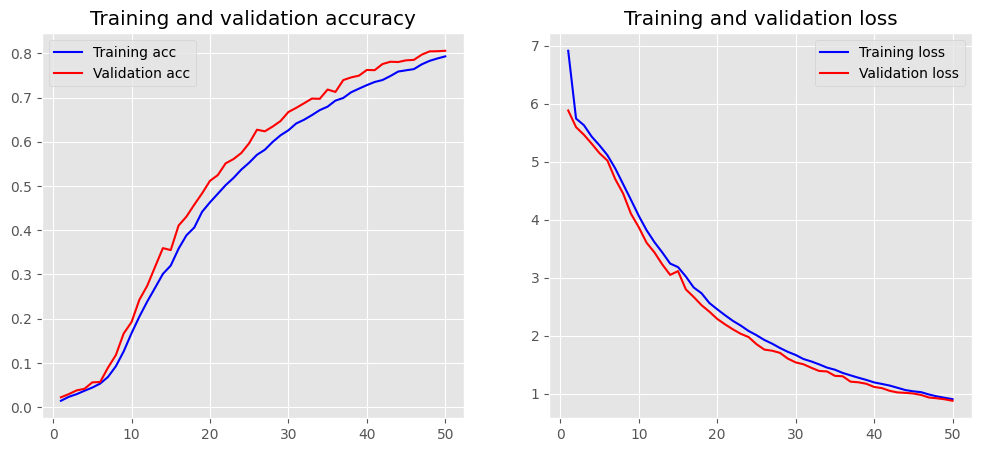

In [ ]:
plot_history(history3)

In [ ]:
display_model_score(model_bilstm, train_pad, y_train, val_pad, y_val, test_pad, y_test, batch_size=256)

196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8788 - loss: 0.6105
Train loss:  0.6096118688583374
Train accuracy:  0.8795199990272522
----------------------------------------------------------------------
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7968 - loss: 0.9071
Val loss:  0.8812587857246399
Val accuracy:  0.8055999875068665
----------------------------------------------------------------------
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8014 - loss: 0.8887
Test loss:  0.8934130072593689
Test accuracy:  0.8041999936103821


## **Un CNN suivi d'un LSTM**

In [ ]:
from tensorflow.keras.layers import Input, Embedding, Conv1D, MaxPooling1D, LSTM, Dropout, Dense
from tensorflow.keras.models import Model

x_input = Input(shape=(100,))
emb = Embedding(21,128)(x_input)  # (100,128)

x = Conv1D(filters=128, kernel_size=3, activation='relu', padding='same')(emb)  # (100,128)
#x = MaxPooling1D(pool_size=2)(x)  # (50,128)
x = LSTM(64,kernel_regularizer=l2(0.01))(x)  # (64,)

# Étape 4 : Dense + Softmax
x = Dropout(0.3)(x)
output = Dense(1000, activation='softmax')(x)  # (1000,)

# Modèle
model_cnn_lstm = Model(inputs=x_input, outputs=output)
model_cnn_lstm.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_cnn_lstm.summary()


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_7 (Embedding)         │ (None, 100, 128)       │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 100, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1000)           │        65,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 166,376 (649.91 KB)

 Trainable params: 166,376 (649.91 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history4 = model_cnn_lstm .fit(
    train_pad, y_train,
    epochs=50, batch_size=256,
    validation_data=(val_pad, y_val),
    callbacks=[es3]
    )

Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.0074 - loss: 7.3170 - val_accuracy: 0.0192 - val_loss: 6.0551
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.0173 - loss: 6.0269 - val_accuracy: 0.0204 - val_loss: 5.8780
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.0209 - loss: 5.8784 - val_accuracy: 0.0246 - val_loss: 5.7764
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.0237 - loss: 5.7759 - val_accuracy: 0.0310 - val_loss: 5.6465
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.0283 - loss: 5.6313 - val_accuracy: 0.0356 - val_loss: 5.5120
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.0347 - loss: 5.4731 - val_accuracy: 0.0484 - val_loss: 5.3442
Epoch 7/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.0411 - loss: 5.3200 - val_accuracy: 0.0538 - val_loss: 5.1837
Epoch 8/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.0508 - loss: 5.1832 - val_accu

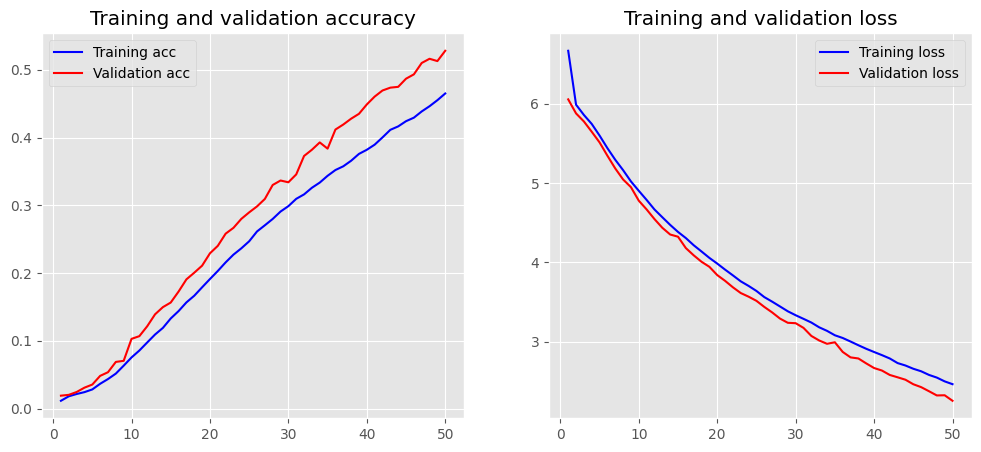

In [ ]:
plot_history(history4)

In [ ]:
display_model_score(model_cnn_lstm, train_pad, y_train, val_pad, y_val, test_pad, y_test, batch_size=256)

196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5815 - loss: 2.0361
Train loss:  2.048764705657959
Train accuracy:  0.5794399976730347
----------------------------------------------------------------------
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5207 - loss: 2.2819
Val loss:  2.2540531158447266
Val accuracy:  0.527999997138977
----------------------------------------------------------------------
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5141 - loss: 2.3098
Test loss:  2.30405330657959
Test accuracy:  0.5217999815940857


Comparaison : LSTM à 2 - BiLSTM - CNN + LSTM
 print
Modèle                        | Paramètres | Train accuracy | Val accuracy | Test accuracy | Observation
----------------------------- | ---------- | -------------- | ------------ | ------------- | ------------------------------------------------------------
LSTM à 2 couches + Dropout     | 248,680    | 41.8%          | 37.7%        | 38.1%         | Malgré le dropout, le modèle a très peu appris (accuracy < 40%); Très faible performance, réseau trop simple ou mal adapté aux données.
BiLSTM                         | 230,504    | 87.95%         | 80.56%       | 80.42%        | Excellente performance ; La lecture bidirectionnelle améliore énormément la compréhension des séquences : le réseau voit à la fois le passé et le futur ; très bon compromis train/val.
CNN + LSTM                     | 166,376    | 57.94%         | 52.8%        | 52.18%        | Performance moyenne ;  faibles en paramétres (166k); meilleur que LSTM simple mais moins performant que BiLSTM .

